In [1]:
import pandas as pd

orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')

In [2]:
print(orders.shape)
print(customers.shape)
print(items.shape)
print(payments.shape)
print(products.shape)

(99441, 8)
(99441, 5)
(112650, 7)
(103886, 5)
(32951, 9)


In [3]:
df = orders.merge(customers, on='customer_id', how='left')

In [4]:
df = df.merge(items, on='order_id', how='left')

In [5]:
df = df.merge(payments, on='order_id', how='left')

In [6]:
df = df.merge(products, on='product_id', how='left')

In [7]:
df.shape

(118434, 30)

In [8]:
df.dropna(inplace=True)

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [9]:
df.to_csv('../data/processed/cleaned.csv', index=False)

In [10]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113390 entries, 0 to 118433
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113390 non-null  object        
 1   customer_id                    113390 non-null  object        
 2   order_status                   113390 non-null  object        
 3   order_purchase_timestamp       113390 non-null  datetime64[ns]
 4   order_approved_at              113390 non-null  object        
 5   order_delivered_carrier_date   113390 non-null  object        
 6   order_delivered_customer_date  113390 non-null  object        
 7   order_estimated_delivery_date  113390 non-null  object        
 8   customer_unique_id             113390 non-null  object        
 9   customer_zip_code_prefix       113390 non-null  int64         
 10  customer_city                  113390 non-null  object        
 11  custo

In [11]:
date_cols = [
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [12]:
numeric_cols = [
    'payment_installments', 'payment_sequential', 'order_item_id'
]

df[numeric_cols] = df[numeric_cols].astype(int)

In [13]:
df = df.drop_duplicates()

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='year_month'>

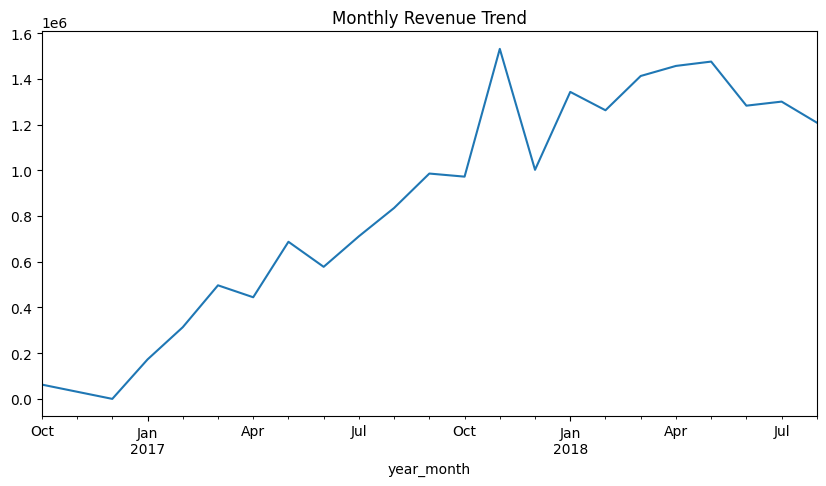

In [14]:
monthly_revenue = df.groupby('year_month')['payment_value'].sum()

monthly_revenue.plot(figsize=(10,5), title="Monthly Revenue Trend")

<Axes: title={'center': 'Top Categories'}, xlabel='product_category_name'>

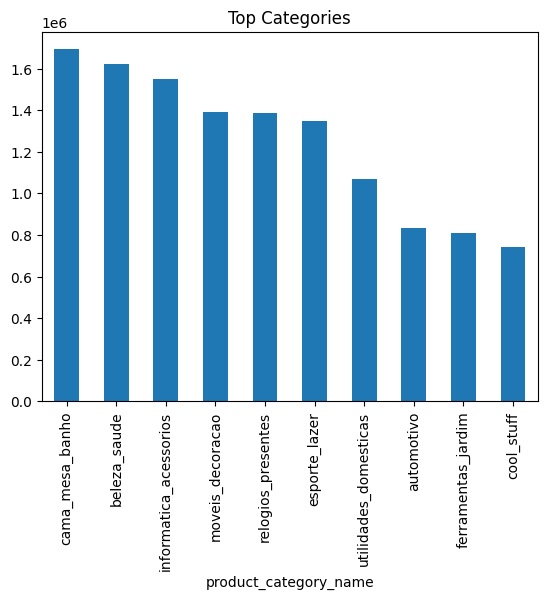

In [15]:
top_products = df.groupby('product_category_name')['payment_value'] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

top_products.plot(kind='bar', title="Top Categories")

In [16]:
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()

customer_orders.describe()

count    92081.000000
mean         1.033090
std          0.206859
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         14.000000
Name: order_id, dtype: float64

In [20]:
customer_revenue = df.groupby('customer_unique_id')['payment_value'].sum()

top_20 = customer_revenue.quantile(0.80)

high_value_customers = customer_revenue[customer_revenue >= top_20]

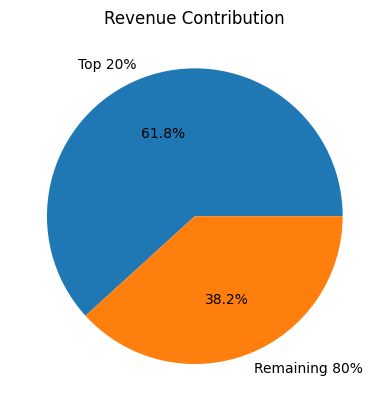

In [22]:
import matplotlib.pyplot as plt

labels = ['Top 20%', 'Remaining 80%']
values = [top_revenue, total_revenue - top_revenue]

plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Revenue Contribution")
plt.show()

In [19]:
state_sales = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)

state_sales.head(10)

customer_state
SP    7313343.77
RJ    2658069.22
MG    2257861.24
RS    1090171.76
PR    1020152.26
BA     762368.88
SC     758705.52
GO     482929.45
DF     418039.12
ES     396343.83
Name: payment_value, dtype: float64

In [23]:
import datetime as dt

snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

In [90]:
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
0000f46a3911fa3c0805444483337064,536,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62
0004aac84e0df4da2b147fca70cf8255,287,1,196.89


In [95]:
rfm.describe()

,Recency,Frequency,Monetary
count,92081.000000,92081.000000,92081.000000
mean,236.219122,1.033090,212.101338
std,152.584190,0.206859,643.626746
min,0.000000,1.000000,9.590000
25%,113.000000,1.000000,63.830000
50%,217.000000,1.000000,112.820000
75%,345.000000,1.000000,202.150000
max,694.000000,14.000000,109312.640000


In [93]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [94]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [97]:
def segment(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [105]:
rfm['Segment'].value_counts()

Segment
Loyal Customers    35890
Others             33195
At Risk            22054
Champions            942
Name: count, dtype: int64

In [106]:
rfm.reset_index().to_csv('../data/processed/rfm.csv', index=False)

In [99]:
rfm['Segment'].value_counts(normalize=True) * 100

Segment
Loyal Customers    38.976553
Others             36.049782
At Risk            23.950652
Champions           1.023012
Name: proportion, dtype: float64

In [100]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Loyal Customers    7532346.30
Others             6650492.34
At Risk            4697413.66
Champions           650251.04
Name: Monetary, dtype: float64

In [101]:
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

Segment
Champions          690.287728
At Risk            212.995994
Loyal Customers    209.873121
Others             200.346207
Name: Monetary, dtype: float64